# Almond Orchard Water Use 

## Numbers and examples


Include literature here and create an example

## Snippets of TECHNICAL REPORT - determining the water requirements of tree nut crops in the main production areas of Portugal
* The intensification of almond production in Portugal is a recent phenomenon, as the acreage of new intensive plantations has gone from less than 2.000 ha in 2014 to more than 26.000 ha in 2020. Irrigation is indispensable to achieve high productivity in Portugal. (maybe give a calculation)

* Methodology used: After determining ETc, the net irrigation requirements are computed based on the effective rainfall and the water
budget of the crop root zone. Such irrigation requirements are calculated for the different areas and for a period of 11 years over the last two decades to capture the temporal variability. They represent the net irrigation demand needed to achieve maximum production in an average year.

* Maximum Kc values are typically reached on July-August, ranging from 0.95 to 1.10. However, more recent data from California suggests that almond Kc maximum values of mature orchards irrigated with microsprinklers may reach values as high as 1.2 (Goldhamer & Girona, 2012). High Kc values, close to 1.2, have been also reported in Australia (Stevens et al., 2011). Higher Kc values are likely due to the increase in planting densities in recent plantations, larger tree canopies due to less annual pruning, and higher fruit loads. Additionally, more frequent soil wetting due to high-frequency irrigation can also increase direct soil surface evaporation which may also contribute to high Kc values. With this background, the almond crop coefficients used here are based on direct ETc field measurements conducted during 10 years in Córdoba, Spain, using a weighing lysimeter installed in 2009 (the only weighing lysimeter of almond in the world until recently), as reported in three consecutive doctoral theses (i.e., Espadafor, 2015; López-López, 2018 and Moldero, 2021).

```{figure} figures/crop_factors.PNG
---
height: 300px
name: directive-fig
---
Crop factors used
```
the optimal deficit irrigation program for almond should prioritize supplying the full ETc in the following periods:

1. Fruit set and early canopy growth (normally achieved if the winter had normal rainfall and the soil is fully charged at flowering)
2. Post-harvest period when the floral buds of the following season are formed. Normally, a month duration after harvest is considered minimum, then some water deficits may be applied later, as the end of the season approaches.
3. Severe water deficits should be always avoided; ETa should not be below 50% of ETc throughout the season.

```{figure} almond_irrigation_requirement.PNG
---
height: 300px
name: directive-fig
---
70 percent canopy over orchard (CC=70%) (López-López et al., 2018)
```


# What we will do here:
1. Estimate ETref/ETpot/ETact for case study fields
2. Get rainfall
3. Get irrigation quota (http://simulador.edia.pt/)
4. What do we see?

## Potential and Actual almond evaporation

I got some data from: https://data.apps.fao.org/wapor/?lang=en for Rota Única Farm 

* Daily Reference ET (df_ETref) -- daily, 30 km (I think it is Penmann Monteith)
* Dekadal ET, ETref, Precipitation (wondering if P is cumulative - otherwise it is pretty useless) -- dekadal, 300 m

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os


# Load ETref
df_ETref = pd.read_csv(
    os.path.join('Data/Evaporation', 'Ref_ET.csv'),
    index_col=0,
    header=0,
    names=['ETref'],
    delimiter=';',
    decimal=','
)
df_ETref.index = pd.to_datetime(df_ETref.index)
df_ETref = df_ETref[~df_ETref.index.duplicated(keep='first')]

# Load Precipitation
df_prec = pd.read_csv(
    os.path.join('Data/Evaporation', 'CHIRPS_Daily_Precipitation.csv'),
    index_col=1,
    header=0
)
df_prec.index = pd.to_datetime(df_prec.index)
df_prec = df_prec.rename(columns={'precip_mm': 'Precip'})  # Optional: rename for clarity

df_prec = df_prec[~df_prec.index.duplicated(keep='first')]
df_prec = df_prec[['Precip']]

# Load NDVI
df_ndvi = pd.read_csv(
    os.path.join('Data/extended', 'NDVI_TimeSeries_PerFeature_ext_vc2.csv'),
    index_col=7,
    header=0
)
df_ndvi.index = pd.to_datetime(df_ndvi.index)
df_ndvi = df_ndvi.rename(columns={'NDVI_mean': 'NDVI'}) if 'NDVI_mean' in df_ndvi.columns else df_ndvi
df_ndvi = df_ndvi[['NDVI']] if 'NDVI' in df_ndvi.columns else df_ndvi.iloc[:, [0]]
df_ndvi = df_ndvi[~df_ndvi.index.duplicated(keep='first')]
df_ndvi = df_ndvi[['NDVI']]

# Merge all on the date index
df_merged = pd.concat([df_ETref, df_prec, df_ndvi], axis=1)

# Sort index (optional but tidy)
df_merged = df_merged.sort_index()

# interpolate NDVI
df_merged['NDVI'][df_merged['NDVI'] < 0.1] = np.nan
df_merged['NDVI'] = df_merged['NDVI'].interpolate()

# select focus
df_merged = df_merged['2018-01-01':'2025-01-01']

df_merged
# Final preview
print(df_merged.head())
print(df_merged.info())

            ETref    Precip      NDVI
2018-01-01    0.6   0.00000  0.203622
2018-01-02    0.6   0.00000  0.206655
2018-01-03    0.7   0.00000  0.209688
2018-01-04    0.6  14.90844  0.212722
2018-01-05    0.6   0.00000  0.215755
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2018-01-01 to 2025-01-01
Freq: D
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ETref   2558 non-null   float64
 1   Precip  2558 non-null   float64
 2   NDVI    2558 non-null   float64
dtypes: float64(3)
memory usage: 79.9 KB
None


C:\Users\ici-1\AppData\Local\Temp\ipykernel_13980\3585435158.py:51: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_merged['NDVI'][df_merged['NDVI'] < 0.1] = np.nan


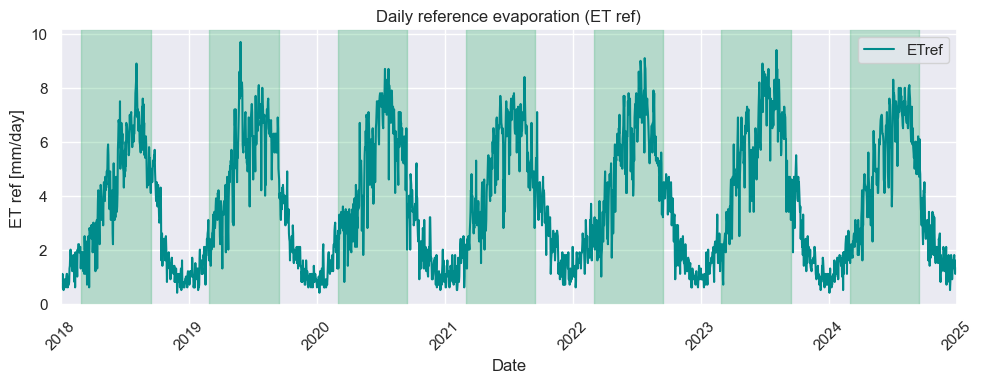

In [23]:
# === Plot NDVI time series with min/max around median ===
sns.set_theme()

fig, ax = plt.subplots(figsize=(10, 4))


df_merged['ETref'].plot(color='darkcyan', ax=ax)

# Loop through each year and color the background for March to September
for year in range(df_merged['ETref'].index.year.min(), df_merged['ETref'].index.year.max() + 1):
    start_date = pd.Timestamp(f'{year}-03-01')  # March 1st of the year
    end_date = pd.Timestamp(f'{year}-09-15')   # September 30th of the year
    ax.axvspan(start_date, end_date, color='mediumseagreen', alpha=0.3)

# Labels and legend
plt.title('Daily reference evaporation (ET ref)')
plt.xlabel('Date')
plt.ylabel('ET ref [mm/day]')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# === Show plot ===
plt.show()

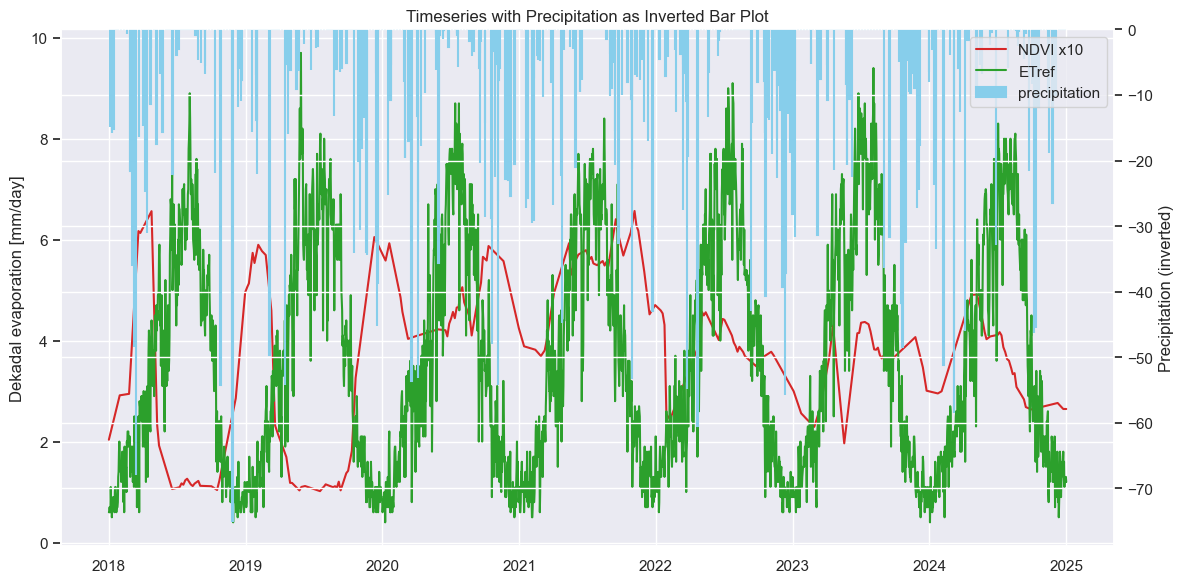

In [24]:
# === Plot NDVI time series with min/max around median ===
sns.set_theme()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Loop through each year and color the background for March to September
for year in range(df_merged.index.year.min(), df_merged.index.year.max() + 1):
    start_date = pd.Timestamp(f'{year}-03-01')  # March 1st of the year
    end_date = pd.Timestamp(f'{year}-09-15')   # September 30th of the year
    ax.axvspan(start_date, end_date, color='mediumseagreen', alpha=0.3)

# Line plots for 
ax1.plot(df_merged.index, df_merged['NDVI']*10, color='tab:red', label='NDVI x10')
ax1.plot(df_merged.index, df_merged['ETref'], color='tab:green', label='ETref')
ax1.set_ylabel('Dekadal evaporation [mm/day]')
# ax1.legend(loc='upper left')

# Secondary y-axis for Precipitation (plotted as a bar plot, top-down)
ax2 = ax1.twinx()
ax2.bar(df_merged.index, -df_merged['Precip'], color='skyblue', edgecolor='skyblue', linewidth=1.5, label='precipitation')
ax2.set_ylabel('Precipitation (inverted)')
# ax2.legend(loc='upper right')

# Optional: make sure the precipitation legend appears
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Timeseries with Precipitation as Inverted Bar Plot')
plt.tight_layout()
plt.show()

### Estimated Crop Factors

TODO: Create a regression with NDVI and Crop factors....

In [25]:
# Define Kc values by month
kc_by_month = {
    1: 0.30,  2: 0.30,  3: 0.40,
    4: 0.60,  5: 0.80,  6: 0.90,
    7: 0.90,  8: 0.85,  9: 0.70,
    10: 0.50, 11: 0.30, 12: 0.30
}

# Add Kc values by mapping the month from the 'date' column
df_merged['Kc'] = df_merged.index.month.map(kc_by_month)

df_merged['PET'] = df_merged['ETref'] * df_merged['Kc'] 
print(df_merged.head())

            ETref    Precip      NDVI   Kc   PET
2018-01-01    0.6   0.00000  0.203622  0.3  0.18
2018-01-02    0.6   0.00000  0.206655  0.3  0.18
2018-01-03    0.7   0.00000  0.209688  0.3  0.21
2018-01-04    0.6  14.90844  0.212722  0.3  0.18
2018-01-05    0.6   0.00000  0.215755  0.3  0.18


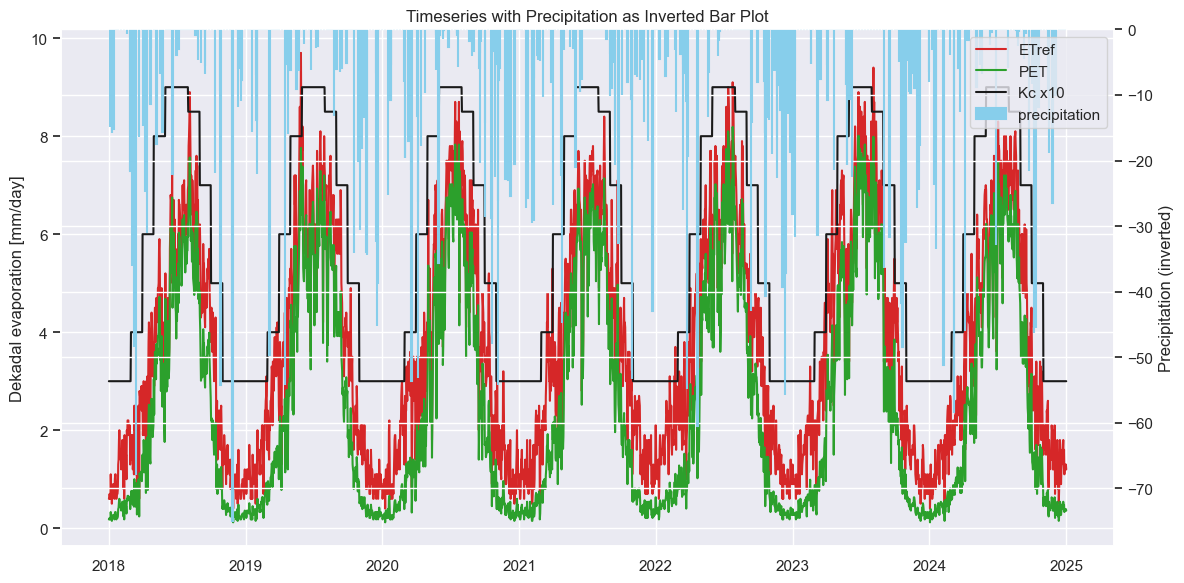

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Loop through each year and color the background for March to September
for year in range(df_merged.index.year.min(), df_merged.index.year.max() + 1):
    start_date = pd.Timestamp(f'{year}-03-01')  # March 1st of the year
    end_date = pd.Timestamp(f'{year}-09-15')   # September 30th of the year
    ax.axvspan(start_date, end_date, color='mediumseagreen', alpha=0.3)

# Secondary y-axis for Precipitation (plotted as a bar plot, top-down)
ax2 = ax1.twinx()
ax2.bar(df_merged.index, -df_merged['Precip'], color='skyblue', edgecolor='skyblue', linewidth=1.5, label='precipitation')
ax2.set_ylabel('Precipitation (inverted)')
# ax2.legend(loc='upper right')

# Line plots for 
ax1.plot(df_merged.index, df_merged['ETref'], color='tab:red', label='ETref')
ax1.plot(df_merged.index, df_merged['PET'], color='tab:green', label='PET')
ax1.plot(df_merged.index, df_merged['Kc']*10, color='k', label='Kc x10')
ax1.set_ylabel('Dekadal evaporation [mm/day]')
# ax1.legend(loc='upper left')

# Optional: make sure the precipitation legend appears
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Timeseries with Precipitation as Inverted Bar Plot')
plt.tight_layout()
plt.show()

In [28]:
# water deficit:
df_merged['Irrigation requirement'] = df_merged['PET'] - df_merged['Precip']

df_merged['Irrigation requirement'][df_merged['Irrigation requirement']<0] = 0
print(df_merged.head())

            ETref    Precip      NDVI   Kc   PET  Irrigation requirement
2018-01-01    0.6   0.00000  0.203622  0.3  0.18                    0.18
2018-01-02    0.6   0.00000  0.206655  0.3  0.18                    0.18
2018-01-03    0.7   0.00000  0.209688  0.3  0.21                    0.21
2018-01-04    0.6  14.90844  0.212722  0.3  0.18                    0.00
2018-01-05    0.6   0.00000  0.215755  0.3  0.18                    0.18


C:\Users\ici-1\AppData\Local\Temp\ipykernel_13980\858634388.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_merged['Irrigation requirement'][df_merged['Irrigation requirement']<0] = 0


In [29]:
df_merged['2022-01-01':'2022-12-31'].sum()

ETref                     1402.200000
Precip                     789.874229
NDVI                       135.539456
Kc                         208.950000
PET                        982.665000
Irrigation requirement     930.739178
dtype: float64

       ETref      Precip        NDVI      Kc       PET  \
year                                                     
2018  1204.8  822.138323   94.403365  208.95   857.395   
2019  1357.3  589.891532  105.781049  208.95   960.390   
2020  1332.1  816.661684  175.501365  209.25   941.400   
2021  1355.4  631.388915  190.019055  208.95   949.110   
2022  1402.2  789.874229  135.539456  208.95   982.665   
2023  1450.1  623.845733  124.284762  208.95  1026.155   
2024  1353.5  642.282514  127.042824  209.25   955.595   
2025     1.2    0.000000    0.264528    0.30     0.360   

      Irrigation requirement  month  
year                                 
2018              799.395307   2382  
2019              900.382312   2382  
2020              865.263936   2384  
2021              874.669930   2382  
2022              930.739178   2382  
2023              973.655000   2382  
2024              899.071078   2384  
2025                0.360000      1  


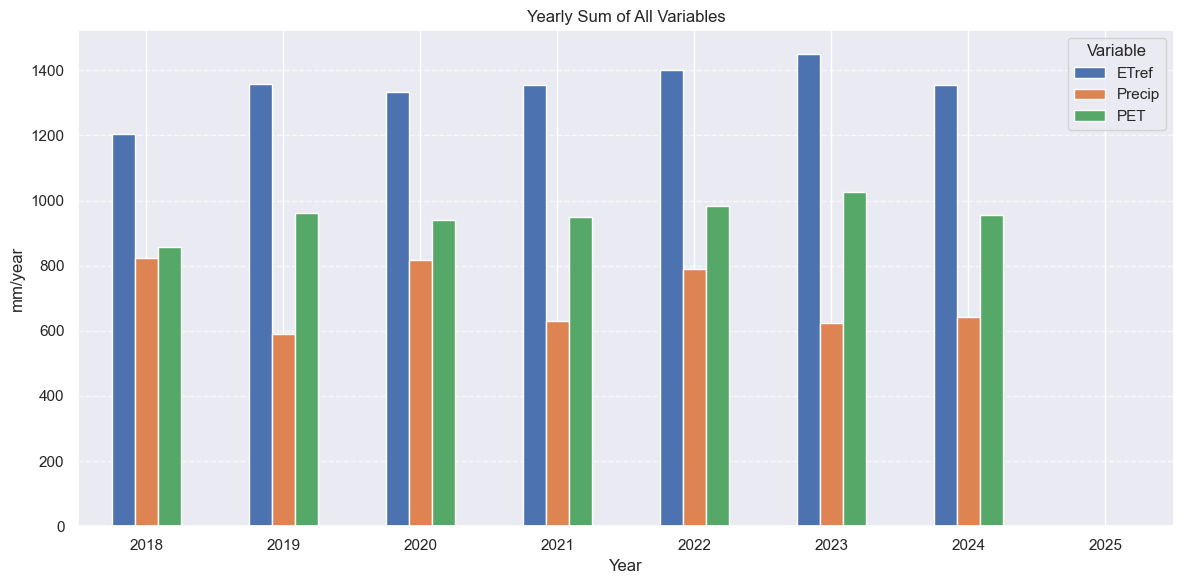

In [31]:
df_merged['year'] = df_merged.index.year
df_merged['month'] = df_merged.index.month

# Group by year and sum all other columns
yearly_sum = df_merged.groupby('year').sum(numeric_only=True)

# Drop 'year' column if it was included (can happen with some settings)
if 'year' in yearly_sum.columns:
    yearly_sum = yearly_sum.drop(columns=['year'])

print(yearly_sum)
# Plot
ax = yearly_sum[['ETref', 'Precip', 'PET']].plot(kind='bar', figsize=(12, 6))

plt.title('Yearly Sum of All Variables')
plt.xlabel('Year')
plt.ylabel('mm/year')
plt.xticks(rotation=0)
plt.legend(title='Variable')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

   year   ETref      Precip        NDVI      Kc      PET  \
0  2018  1067.0  545.594551   60.517942  172.95  816.055   
1  2019  1204.4  256.035674   40.938826  172.95  914.520   
2  2020  1165.7  514.004143  112.036775  172.95  891.480   
3  2021  1183.7  380.992369  134.141658  172.95  897.600   
4  2022  1209.9  424.728669   94.161688  172.95  924.975   
5  2023  1282.2  401.216579   86.578856  172.95  975.785   
6  2024  1175.7  405.426155   91.752046  172.95  902.255   

   Irrigation requirement  month  
0              762.318553   1593  
1              860.817417   1593  
2              822.453936   1593  
3              830.059930   1593  
4              881.779178   1593  
5              930.455000   1593  
6              851.311078   1593  
[192.31855292 290.81741745 252.45393641 260.05993014 311.77917821
 360.455      281.31107831]
[570. 570. 570. 570. 570. 570. 570.]


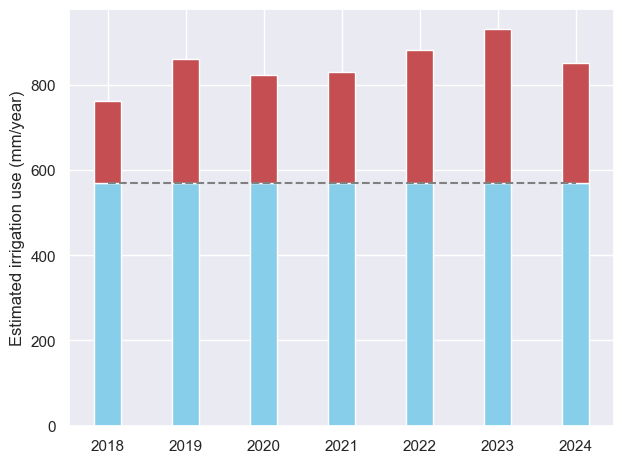

In [47]:
# Filter for months March (3) to September (9)
df_filtered = df_merged[(df_merged['month'] >= 3) & (df_merged['month'] <= 10)]

# Group by year and sum values
yearly_sums = df_filtered.groupby('year').sum().reset_index()

print(yearly_sums)

# some example data
threshold = 570 #mm/year irrigation requirement

# split it up
above_threshold = np.maximum(yearly_sums['Irrigation requirement'].values - threshold, 0)
below_threshold = np.minimum(yearly_sums['Irrigation requirement'].values, threshold)

print(above_threshold)
print(below_threshold)


# and plot it
fig, ax = plt.subplots()
ax.bar(yearly_sums['year'].values, below_threshold, 0.35, color="skyblue")
ax.bar(yearly_sums['year'].values, above_threshold, 0.35, color="r",
        bottom=below_threshold)

# horizontal line indicating the threshold
ax.plot([yearly_sums['year'].min(), yearly_sums['year'].max()], [threshold, threshold], color="gray", linestyle='--')

plt.ylabel('Estimated irrigation use (mm/year)')
plt.tight_layout()
plt.show()

## Next

* reiterate
* flexible crop factors based on regression NDVI-KC
* propose steps to go to ETa 

### Idea to add: Water Productivity graph